In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Cấu hình
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
batch_size = 64
latent_dim = 128
n_classes = 10
img_size = 28 * 28

# Load dữ liệu MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5]) # Đưa về khoảng [-1, 1]
])

dataset = datasets.MNIST(root="./data", train=True, transform=transform, download=True)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.55MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 146kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.38MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 5.73MB/s]


In [2]:
class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        # Embedding cho nhãn
        self.label_emb = nn.Embedding(n_classes, n_classes)
        
        self.model = nn.Sequential(
            nn.Linear(latent_dim + n_classes, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(1024, img_size),
            nn.Tanh() # Đưa đầu ra về khoảng [-1, 1]
        )

    def forward(self, noise, labels):
        # Nối vector nhiễu và vector nhãn
        gen_input = torch.cat((noise, self.label_emb(labels)), -1)
        img = self.model(gen_input)
        return img.view(img.size(0), 1, 28, 28)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.label_emb = nn.Embedding(n_classes, n_classes)
        
        self.model = nn.Sequential(
            nn.Linear(img_size + n_classes, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid() # Xác suất Thật/Giả
        )

    def forward(self, img, labels):
        # Phẳng hóa ảnh và nối với nhãn
        d_input = torch.cat((img.view(img.size(0), -1), self.label_emb(labels)), -1)
        validity = self.model(d_input)
        return validity

In [3]:
generator = Generator().to(device)
discriminator = Discriminator().to(device)

adversarial_loss = nn.BCELoss()
optimizer_G = optim.Adam(generator.parameters(), lr=0.0002, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0002, betas=(0.5, 0.999))

epochs = 20
for epoch in range(epochs):
    for i, (imgs, labels) in enumerate(dataloader):
        batch_size = imgs.shape[0]
        real_imgs = imgs.to(device)
        labels = labels.to(device)

        # Nhãn cho loss (Thật=1, Giả=0)
        valid = torch.ones(batch_size, 1, device=device)
        fake = torch.zeros(batch_size, 1, device=device)

        # --- 1. Huấn luyện Generator ---
        optimizer_G.zero_grad()
        z = torch.randn(batch_size, latent_dim, device=device)
        gen_labels = torch.randint(0, n_classes, (batch_size,), device=device)
        
        gen_imgs = generator(z, gen_labels)
        g_loss = adversarial_loss(discriminator(gen_imgs, gen_labels), valid)
        
        g_loss.backward()
        optimizer_G.step()

        # --- 2. Huấn luyện Discriminator ---
        optimizer_D.zero_grad()
        
        # Kiểm tra ảnh thật
        real_loss = adversarial_loss(discriminator(real_imgs, labels), valid)
        # Kiểm tra ảnh giả
        fake_loss = adversarial_loss(discriminator(gen_imgs.detach(), gen_labels), fake)
        
        d_loss = (real_loss + fake_loss) / 2
        d_loss.backward()
        optimizer_D.step()

    print(f"Epoch {epoch} | D Loss: {d_loss.item():.4f} | G Loss: {g_loss.item():.4f}")

Epoch 0 | D Loss: 0.1679 | G Loss: 2.2772
Epoch 1 | D Loss: 0.2505 | G Loss: 1.6839
Epoch 2 | D Loss: 0.1934 | G Loss: 2.9193
Epoch 3 | D Loss: 0.1837 | G Loss: 2.5491
Epoch 4 | D Loss: 0.0982 | G Loss: 3.3218
Epoch 5 | D Loss: 0.0879 | G Loss: 3.9678
Epoch 6 | D Loss: 0.0184 | G Loss: 5.2934
Epoch 7 | D Loss: 0.0036 | G Loss: 6.2255
Epoch 8 | D Loss: 0.0214 | G Loss: 4.8288
Epoch 9 | D Loss: 0.0065 | G Loss: 7.3068
Epoch 10 | D Loss: 0.0099 | G Loss: 5.6931
Epoch 11 | D Loss: 0.0033 | G Loss: 6.0474
Epoch 12 | D Loss: 0.0000 | G Loss: 11.1006
Epoch 13 | D Loss: 0.0008 | G Loss: 91.0039
Epoch 14 | D Loss: 0.0000 | G Loss: 94.2988
Epoch 15 | D Loss: 0.0000 | G Loss: 88.6068
Epoch 16 | D Loss: 0.0000 | G Loss: 97.1998
Epoch 17 | D Loss: 0.0000 | G Loss: 97.4235
Epoch 18 | D Loss: 0.0000 | G Loss: 85.7769
Epoch 19 | D Loss: 0.0000 | G Loss: 100.0000


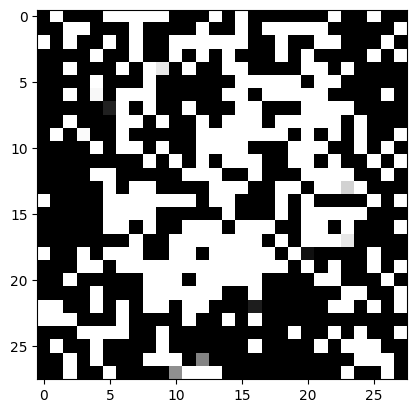

In [4]:
def generate_digit(digit):
    generator.eval()
    z = torch.randn(1, latent_dim, device=device)
    label = torch.LongTensor([digit]).to(device)
    with torch.no_grad():
        img = generator(z, label)
    return img.cpu().squeeze()

# Ví dụ tạo số 7
my_digit = generate_digit(7)
import matplotlib.pyplot as plt
plt.imshow(my_digit, cmap='gray')
plt.show()